In [ ]:
#Diabetic Retinopathy Classification

01_Data_Cleaning_EDA

In [34]:
from PIL import Image
import os

corrupted = []

for root, _, files in os.walk("C:\\Users\\dbda63\\Desktop\\archive\\split_dataset\\train"):
    for file in files:
        path = os.path.join(root, file)

        try:
            img = Image.open(path)
            img.verify()
        except Exception:
            corrupted.append(path)

print("Corrupted Images:", len(corrupted))

Corrupted Images: 0


In [35]:
for img in corrupted:
    os.remove(img)

In [36]:
from PIL import Image
import os

corrupted = []

for root, _, files in os.walk("C:\\Users\\dbda63\\Desktop\\archive\\split_dataset\\test"):
    for file in files:
        path = os.path.join(root, file)

        try:
            img = Image.open(path)
            img.verify()
        except Exception:
            corrupted.append(path)

print("Corrupted Images:", len(corrupted))

Corrupted Images: 0


In [37]:
from PIL import Image
import os

corrupted = []

for root, _, files in os.walk("C:\\Users\\dbda63\\Desktop\\archive\\split_dataset\\val"):
    for file in files:
        path = os.path.join(root, file)

        try:
            img = Image.open(path)
            img.verify()
        except Exception:
            corrupted.append(path)

print("Corrupted Images:", len(corrupted))

Corrupted Images: 0


In [39]:
import hashlib
import os

dataset_path = r"C:\Users\dbda63\Desktop\archive\split_dataset\train"

hashes = {}
duplicates = []

for root, _, files in os.walk(dataset_path):
    for file in files:
        path = os.path.join(root, file)

        with open(path, "rb") as f:
            filehash = hashlib.md5(f.read()).hexdigest()

        if filehash in hashes:
            duplicates.append((hashes[filehash], path))   # Store original + duplicate
        else:
            hashes[filehash] = path

print(f"Total Duplicates: {len(duplicates)}")

Total Duplicates: 0


In [40]:
for original, duplicate in duplicates[:20]:  # Show first 20 pairs
    print("=" * 80)
    print("Original :", original)
    print("Duplicate:", duplicate)
    print("Original Class :", os.path.basename(os.path.dirname(original)))
    print("Duplicate Class:", os.path.basename(os.path.dirname(duplicate)))

In [41]:
cross_class = []

for original, duplicate in duplicates:
    class1 = os.path.basename(os.path.dirname(original))
    class2 = os.path.basename(os.path.dirname(duplicate))

    if class1 != class2:
        cross_class.append((original, duplicate, class1, class2))

print("Cross-class duplicates:", len(cross_class))

for o, d, c1, c2 in cross_class:
    print("=" * 80)
    print(f"{o} ({c1})")
    print(f"{d} ({c2})")

Cross-class duplicates: 0


In [42]:
from PIL import Image
import matplotlib.pyplot as plt

for original, duplicate, class1, class2 in cross_class:

    img1 = Image.open(original)
    img2 = Image.open(duplicate)

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(img1)
    plt.title(f"Class {class1}")
    plt.subplot(1,2,2)
    plt.imshow(img2)
    plt.title(f"Class {class2}")

    plt.show()

In [43]:
import os

deleted = 0

for original, duplicate, class1, class2 in cross_class:
    
    # Delete original image
    if os.path.exists(original):
        os.remove(original)
        deleted += 1

    # Delete duplicate image
    if os.path.exists(duplicate):
        os.remove(duplicate)
        deleted += 1

print(f"Deleted {deleted} conflicting images.")

Deleted 0 conflicting images.


In [43]:
import os

deleted = 0

for original, duplicate, class1, class2 in cross_class:
    
    # Delete original image
    if os.path.exists(original):
        os.remove(original)
        deleted += 1

    # Delete duplicate image
    if os.path.exists(duplicate):
        os.remove(duplicate)
        deleted += 1

print(f"Deleted {deleted} conflicting images.")

Deleted 0 conflicting images.


In [44]:
import os

deleted = 0

for original, duplicate in duplicates:

    class1 = os.path.basename(os.path.dirname(original))
    class2 = os.path.basename(os.path.dirname(duplicate))

    if class1 == class2:
        if os.path.exists(duplicate):
            os.remove(duplicate)
            deleted += 1

print(f"Deleted {deleted} same-class duplicate images.")

Deleted 0 same-class duplicate images.


In [46]:
import hashlib
import os

dataset_path = r"C:\Users\dbda63\Desktop\archive\split_dataset"

hashes = {}
duplicates = []

for root, _, files in os.walk(dataset_path):
    for file in files:
        path = os.path.join(root, file)

        with open(path, "rb") as f:
            filehash = hashlib.md5(f.read()).hexdigest()

        if filehash in hashes:
            duplicates.append((hashes[filehash], path))   # Store original + duplicate
        else:
            hashes[filehash] = path

print(f"Total Duplicates: {len(duplicates)}")

Total Duplicates: 213


In [47]:
for original, duplicate in duplicates[:20]:  # Show first 20 pairs
    print("=" * 80)
    print("Original :", original)
    print("Duplicate:", duplicate)
    print("Original Class :", os.path.basename(os.path.dirname(original)))
    print("Duplicate Class:", os.path.basename(os.path.dirname(duplicate)))

Original : C:\Users\dbda63\Desktop\archive\split_dataset\test\0\20170215104620891.jpg
Duplicate: C:\Users\dbda63\Desktop\archive\split_dataset\test\0\20170216092816210.jpg
Original Class : 0
Duplicate Class: 0
Original : C:\Users\dbda63\Desktop\archive\split_dataset\test\2\135575dc57c9.png
Duplicate: C:\Users\dbda63\Desktop\archive\split_dataset\test\2\2c2aa057afc5.png
Original Class : 2
Duplicate Class: 2
Original : C:\Users\dbda63\Desktop\archive\split_dataset\test\2\0161338f53cc.png
Duplicate: C:\Users\dbda63\Desktop\archive\split_dataset\test\2\cac40227d3b2.png
Original Class : 2
Duplicate Class: 2
Original : C:\Users\dbda63\Desktop\archive\split_dataset\test\2\7877be80901c.png
Duplicate: C:\Users\dbda63\Desktop\archive\split_dataset\test\2\ee2c2a5f7d0e.png
Original Class : 2
Duplicate Class: 2
Original : C:\Users\dbda63\Desktop\archive\split_dataset\test\3\11211_right-600-BF.jpg
Duplicate: C:\Users\dbda63\Desktop\archive\split_dataset\test\3\11211_right-600-FF.jpg
Original Class :

In [48]:
cross_class = []

for original, duplicate in duplicates:
    class1 = os.path.basename(os.path.dirname(original))
    class2 = os.path.basename(os.path.dirname(duplicate))

    if class1 != class2:
        cross_class.append((original, duplicate, class1, class2))

print("Cross-class duplicates:", len(cross_class))

for o, d, c1, c2 in cross_class:
    print("=" * 80)
    print(f"{o} ({c1})")
    print(f"{d} ({c2})")

Cross-class duplicates: 38
C:\Users\dbda63\Desktop\archive\split_dataset\test\2\f7edc074f06b-GF-600.jpg (2)
C:\Users\dbda63\Desktop\archive\split_dataset\test\3\9bf060db8376-GF-600.jpg (3)
C:\Users\dbda63\Desktop\archive\split_dataset\test\1\278aa860dffd.png (1)
C:\Users\dbda63\Desktop\archive\split_dataset\train\0\f066db7a2efe.png (0)
C:\Users\dbda63\Desktop\archive\split_dataset\test\0\42985aa2e32f.png (0)
C:\Users\dbda63\Desktop\archive\split_dataset\train\1\6165081b9021.png (1)
C:\Users\dbda63\Desktop\archive\split_dataset\test\2\8446826853d0.png (2)
C:\Users\dbda63\Desktop\archive\split_dataset\train\1\8ef2eb8c51c4.png (1)
C:\Users\dbda63\Desktop\archive\split_dataset\test\3\fe0fc67c7980.png (3)
C:\Users\dbda63\Desktop\archive\split_dataset\train\2\521d3e264d71.png (2)
C:\Users\dbda63\Desktop\archive\split_dataset\test\4\80964d8e0863.png (4)
C:\Users\dbda63\Desktop\archive\split_dataset\train\2\ab50123abadb.png (2)
C:\Users\dbda63\Desktop\archive\split_dataset\test\1\bacfb1029f6b.

In [49]:
import os

deleted = 0

for original, duplicate, class1, class2 in cross_class:
    
    # Delete original image
    if os.path.exists(original):
        os.remove(original)
        deleted += 1

    # Delete duplicate image
    if os.path.exists(duplicate):
        os.remove(duplicate)
        deleted += 1

print(f"Deleted {deleted} conflicting images.")

Deleted 74 conflicting images.


In [50]:
import os

deleted = 0

for original, duplicate in duplicates:

    class1 = os.path.basename(os.path.dirname(original))
    class2 = os.path.basename(os.path.dirname(duplicate))

    if class1 == class2:
        if os.path.exists(duplicate):
            os.remove(duplicate)
            deleted += 1

print(f"Deleted {deleted} same-class duplicate images.")

Deleted 175 same-class duplicate images.


In [51]:
#EDA

In [52]:
import os

dataset_path = r"C:\Users\dbda63\Desktop\archive\split_dataset\train"

print("Training Dataset Summary")
print("-" * 40)

total = 0

for class_name in sorted(os.listdir(dataset_path)):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])

        total += count
        print(f"Class {class_name}: {count}")

print("-" * 40)
print(f"Total Images: {total}")

Training Dataset Summary
----------------------------------------
Class 0: 5953
Class 1: 5933
Class 2: 5910
Class 3: 5810
Class 4: 5930
----------------------------------------
Total Images: 29536


In [53]:
from PIL import Image
import os

dataset_path = r"C:\Users\dbda63\Desktop\archive\split_dataset\train"

widths = []
heights = []

for root, _, files in os.walk(dataset_path):

    for file in files:

        path = os.path.join(root, file)

        try:
            img = Image.open(path)

            w, h = img.size

            widths.append(w)
            heights.append(h)

        except:
            pass

print("Minimum Width :", min(widths))
print("Maximum Width :", max(widths))
print("Average Width :", sum(widths)/len(widths))

print()

print("Minimum Height :", min(heights))
print("Maximum Height :", max(heights))
print("Average Height :", sum(heights)/len(heights))

Minimum Width : 512
Maximum Width : 4496
Average Width : 744.428900325027

Minimum Height : 480
Maximum Height : 3456
Average Height : 693.7592429577464


In [54]:
from PIL import Image
import os

rgb = 0
gray = 0

for root, _, files in os.walk(dataset_path):

    for file in files:

        path = os.path.join(root, file)

        try:

            img = Image.open(path)

            if img.mode == "RGB":
                rgb += 1
            else:
                gray += 1

        except:
            pass

print("RGB Images :", rgb)
print("Non-RGB Images :", gray)

RGB Images : 29536
Non-RGB Images : 0


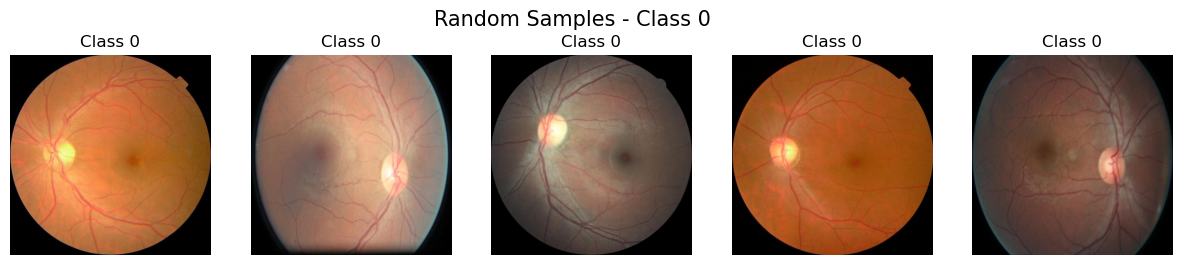

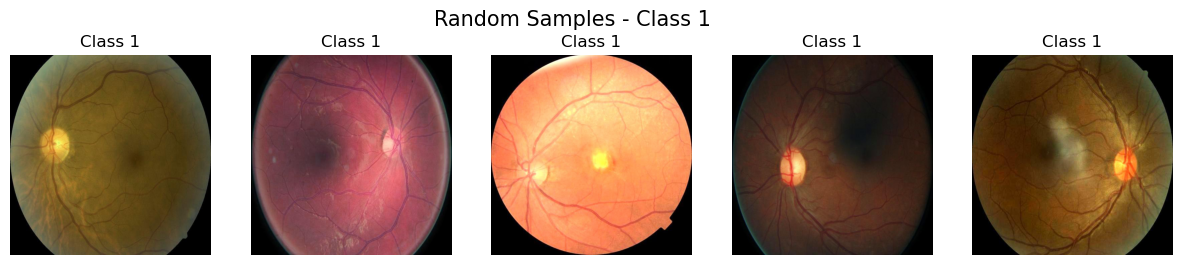

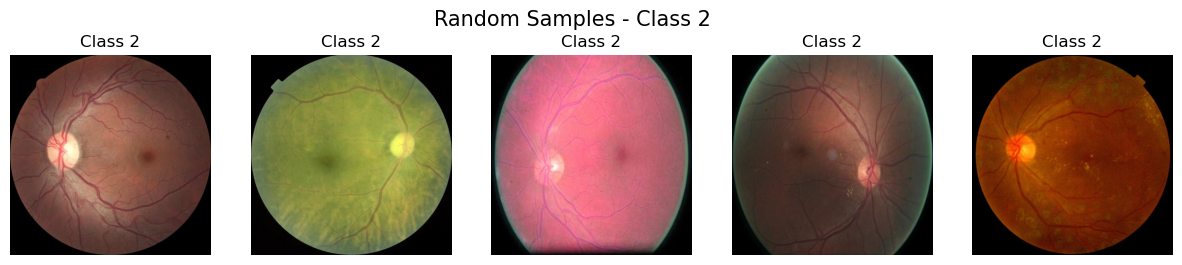

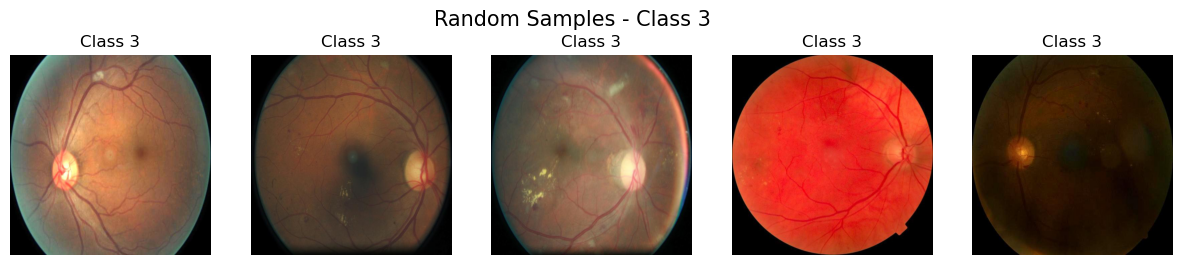

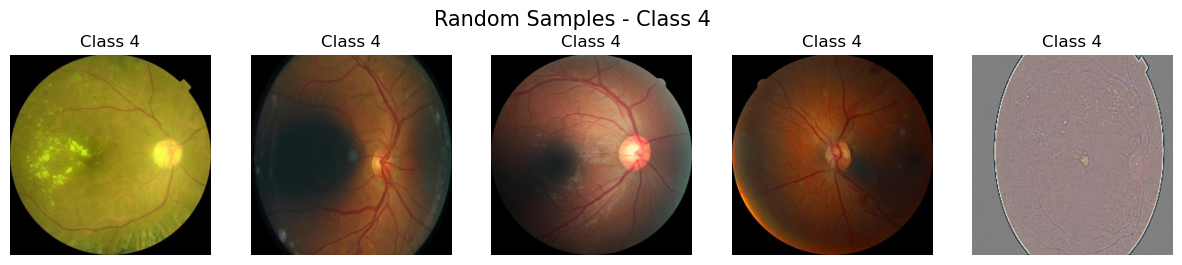

In [55]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = r"C:\Users\dbda63\Desktop\archive\split_dataset\train"

classes = sorted(os.listdir(dataset_path))

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    images = random.sample(os.listdir(class_path), 5)

    plt.figure(figsize=(15,3))

    for i, img_name in enumerate(images):

        img = Image.open(os.path.join(class_path, img_name))

        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Class {cls}")

    plt.suptitle(f"Random Samples - Class {cls}", fontsize=15)
    plt.show()